## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [5]:
df = pd.read_csv(
    "C:\\Users\\Shipra\\OneDrive\\Documents\\GitHub\\CODSOFT_DATASCIENCE\\Movie_RatingPrediction\\IMDb Movies India.csv",
    encoding='latin1',
    on_bad_lines='skip'
)
# Preview data
print(df.head())
print(df.info())

                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

## DATA CLEANING

In [6]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Drop rows where target (Rating) is missing
df = df[df['Rating'].notnull()]


In [7]:
# Fill missing values
df['Genre'].fillna('Unknown', inplace=True)
df['Director'].fillna('Unknown', inplace=True)
df['Actor 1'].fillna('Unknown', inplace=True)
df['Actor 2'].fillna('Unknown', inplace=True)
df['Actor 3'].fillna('Unknown', inplace=True)


C:\Users\Shipra\AppData\Local\Temp\ipykernel_21920\1758949783.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Genre'].fillna('Unknown', inplace=True)
C:\Users\Shipra\AppData\Local\Temp\ipykernel_21920\1758949783.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment us

1          Arvind Jangid
3        Siddhant Kapoor
5          Shammi Kapoor
6         Yashpal Sharma
8           Kiran Bhatia
              ...       
15501            Govinda
15503        Rajinikanth
15504      Suparna Anand
15505        Aruna Irani
15508        Arjun Sarja
Name: Actor 3, Length: 7919, dtype: str

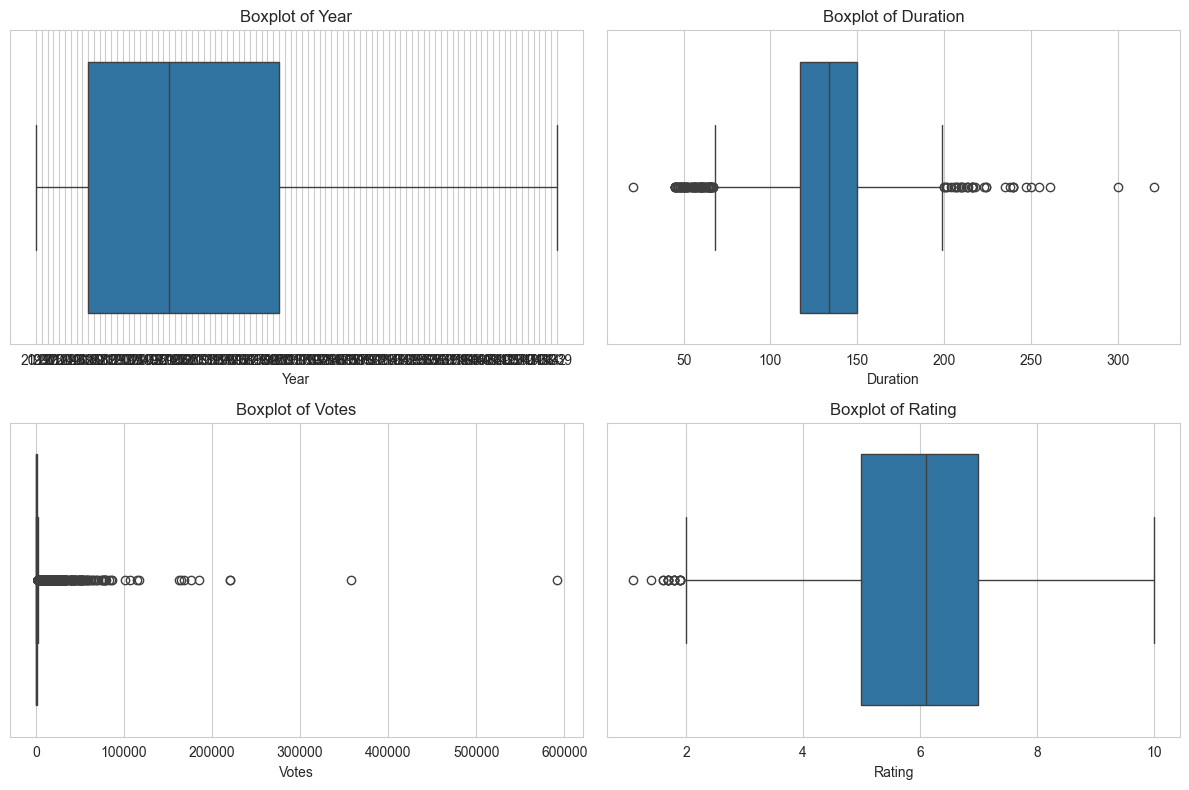

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Year', 'Duration', 'Votes', 'Rating']

plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [40]:
# Convert columns to numeric properly
cols = ['Year', 'Duration', 'Votes', 'Rating']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where conversion failed
df.dropna(subset=cols, inplace=True)

# Verify
print(df[cols].dtypes)

Year          int64
Duration    float64
Votes         int64
Rating      float64
dtype: object


In [41]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")
    return outliers

# Check all columns
for col in ['Year', 'Duration', 'Votes', 'Rating']:
    detect_outliers_iqr(df, col)

Year: 34 outliers
Duration: 121 outliers
Votes: 954 outliers
Rating: 18 outliers


In [42]:
# Clean before conversion

df['Duration'] = df['Duration'].astype(str).str.replace(' min', '', regex=False)
df['Votes'] = df['Votes'].astype(str).str.replace(',', '', regex=False)
df['Year'] = df['Year'].astype(str).str.extract('(\d+)')

# Then convert
cols = ['Year', 'Duration', 'Votes', 'Rating']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=cols, inplace=True)

<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Shipra\AppData\Local\Temp\ipykernel_21920\2455886745.py:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['Year'] = df['Year'].astype(str).str.extract('(\d+)')


In [43]:
print(df[['Year','Duration','Votes','Rating']].head())
print(df[['Year','Duration','Votes','Rating']].dtypes)

   Year  Duration  Votes  Rating
1  2019     109.0      8     7.0
3  2019     110.0     35     4.4
5  1997     147.0    827     4.7
6  2005     142.0   1086     7.4
8  2012      82.0    326     5.6
Year          int64
Duration    float64
Votes         int64
Rating      float64
dtype: object


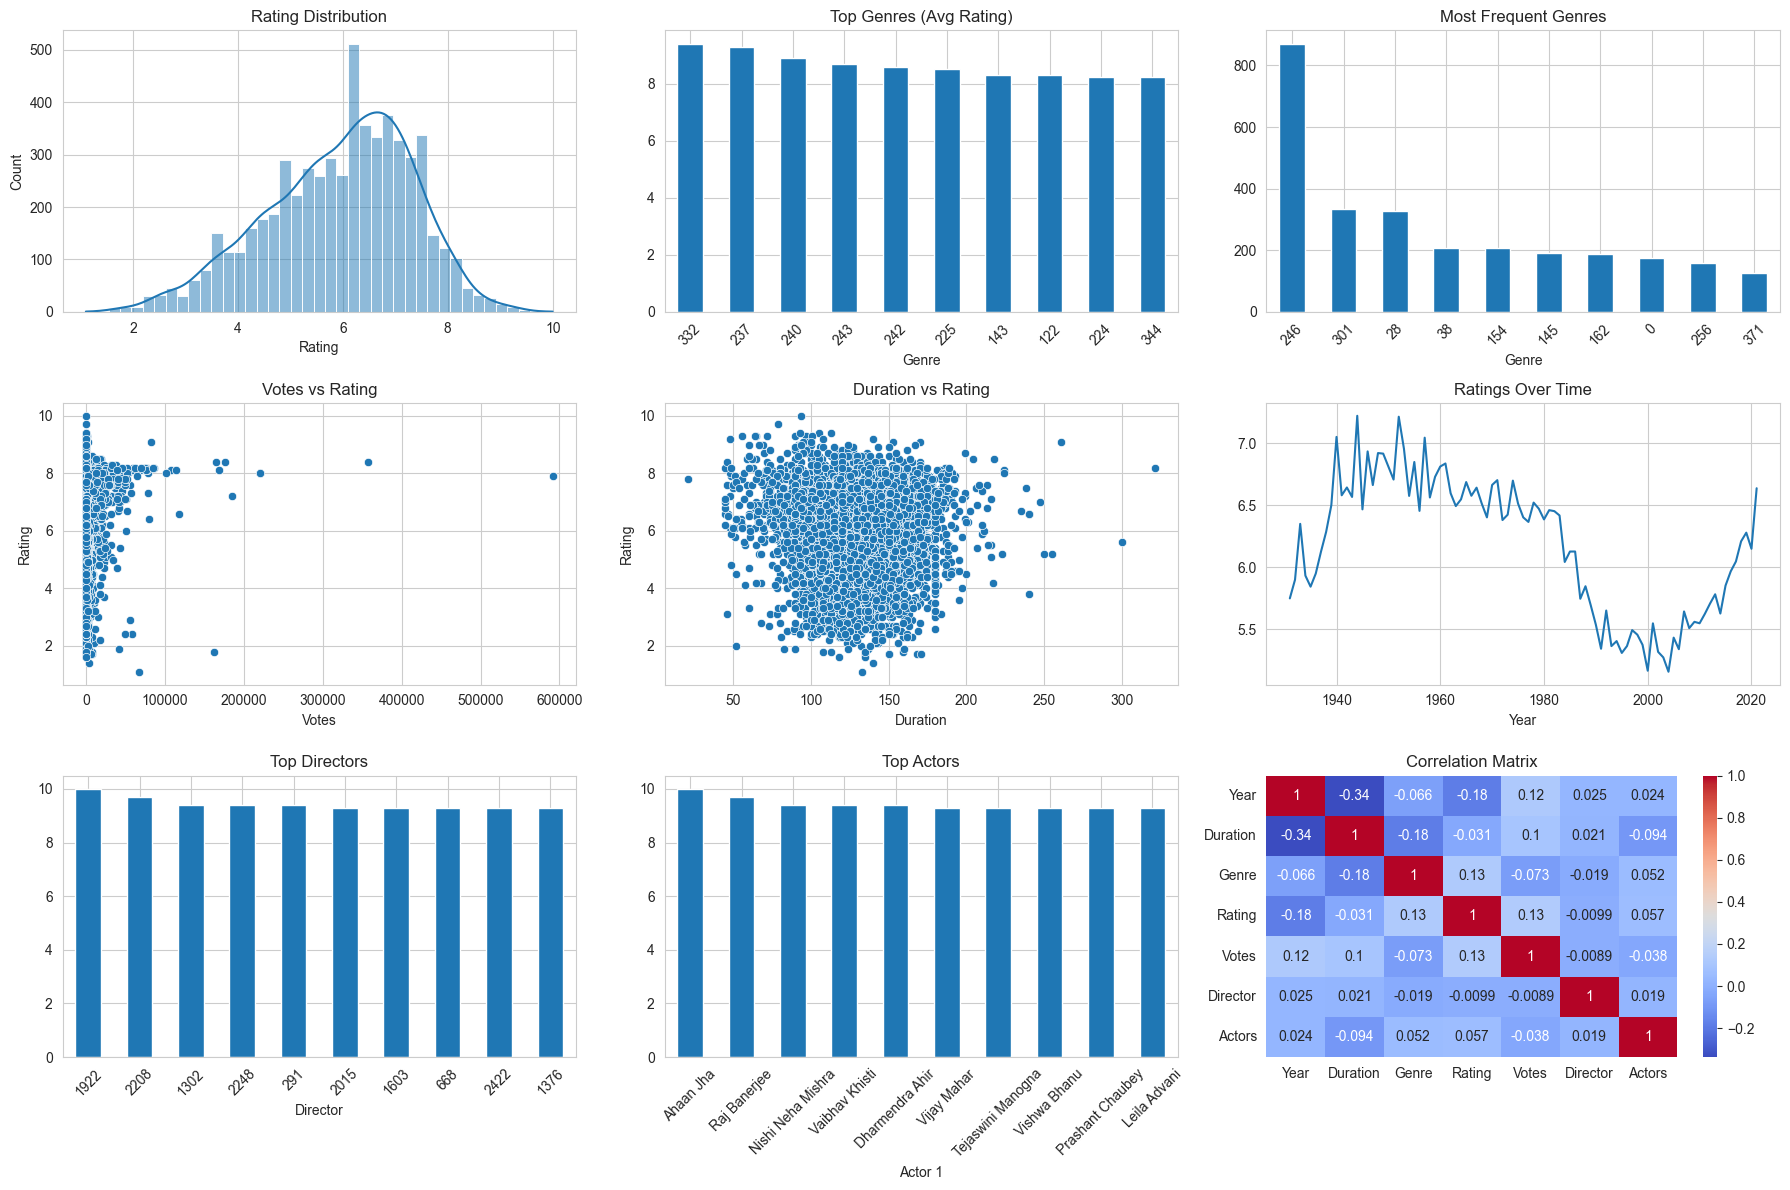

In [44]:
# =========================================
# DASHBOARD VISUALIZATION
# =========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

fig = plt.figure(figsize=(18, 12))

# =========================================
# 1. Rating Distribution
# =========================================
plt.subplot(3, 3, 1)
sns.histplot(df['Rating'], kde=True)
plt.title("Rating Distribution")

# =========================================
# 2. Top Genres by Average Rating
# =========================================
plt.subplot(3, 3, 2)
genre_rating = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False).head(10)
genre_rating.plot(kind='bar')
plt.title("Top Genres (Avg Rating)")
plt.xticks(rotation=45)

# =========================================
# 3. Most Frequent Genres
# =========================================
plt.subplot(3, 3, 3)
df['Genre'].value_counts().head(10).plot(kind='bar')
plt.title("Most Frequent Genres")
plt.xticks(rotation=45)

# =========================================
# 4. Votes vs Rating
# =========================================
plt.subplot(3, 3, 4)
sns.scatterplot(x=df['Votes'], y=df['Rating'])
plt.title("Votes vs Rating")

# =========================================
# 5. Duration vs Rating
# =========================================
plt.subplot(3, 3, 5)
sns.scatterplot(x=df['Duration'], y=df['Rating'])
plt.title("Duration vs Rating")

# =========================================
# 6. Year vs Rating Trend
# =========================================
plt.subplot(3, 3, 6)
df.groupby('Year')['Rating'].mean().plot()
plt.title("Ratings Over Time")

# =========================================
# 7. Top Directors
# =========================================
plt.subplot(3, 3, 7)
df.groupby('Director')['Rating'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Directors")
plt.xticks(rotation=45)

# =========================================
# 8. Top Actors
# =========================================
plt.subplot(3, 3, 8)
df.groupby('Actor 1')['Rating'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Actors")
plt.xticks(rotation=45)

# =========================================
# 9. Correlation Heatmap
# =========================================
plt.subplot(3, 3, 9)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [45]:
# Clean 'Year' column (remove brackets if present)
df['Year'] = df['Year'].astype(str).str.extract('(\d+)')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Clean 'Duration' column (remove 'min')
df['Duration'] = df['Duration'].astype(str).str.replace(' min', '')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

# Clean 'Votes'
df['Votes'] = df['Votes'].astype(str).str.replace(',', '')
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

# Drop rows with essential missing values
df.dropna(subset=['Year', 'Duration', 'Votes'], inplace=True)


<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Shipra\AppData\Local\Temp\ipykernel_21920\440929893.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['Year'] = df['Year'].astype(str).str.extract('(\d+)')


In [9]:
 df['Year'] = df['Year'].astype(str).str.extract('(\d+)')

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Shipra\AppData\Local\Temp\ipykernel_21920\3403743102.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['Year'] = df['Year'].astype(str).str.extract('(\d+)')


In [46]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3', 'Actors'],
      dtype='str')

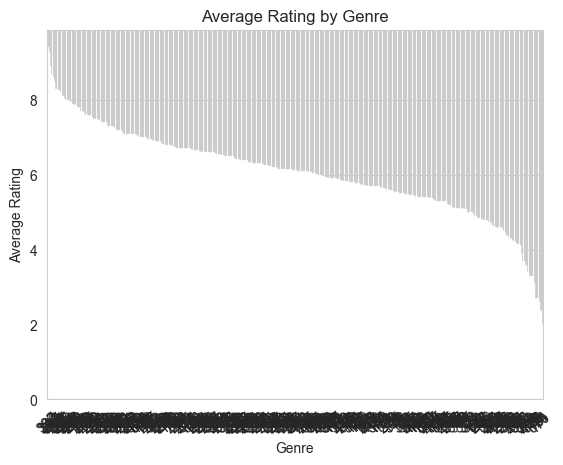

Top Rated Genres:
 Genre
332    9.40
237    9.30
240    8.90
243    8.70
242    8.60
225    8.50
143    8.30
122    8.30
224    8.25
344    8.25
Name: Rating, dtype: float64


In [47]:
genre_rating = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False)

plt.figure()
genre_rating.plot(kind='bar')
plt.title("Average Rating by Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

print("Top Rated Genres:\n", genre_rating.head(10))

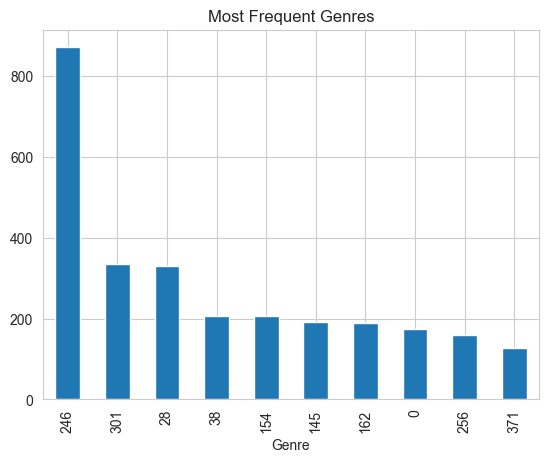

In [48]:
genre_count = df['Genre'].value_counts()

plt.figure()
genre_count.head(10).plot(kind='bar')
plt.title("Most Frequent Genres")
plt.show()

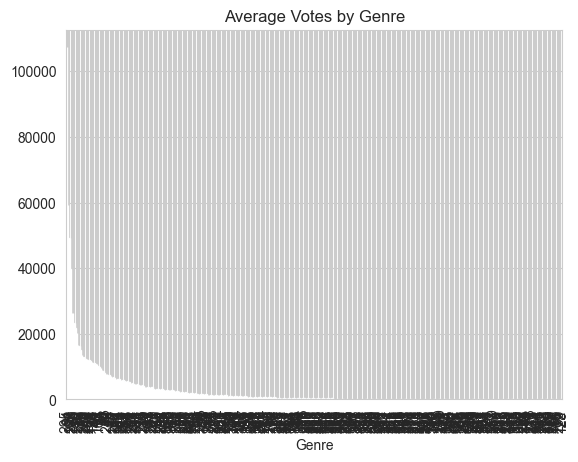

In [49]:
genre_votes = df.groupby('Genre')['Votes'].mean().sort_values(ascending=False)

plt.figure()
genre_votes.plot(kind='bar')
plt.title("Average Votes by Genre")
plt.show()

In [50]:
top_directors = df.groupby('Director')['Rating'].mean().sort_values(ascending=False)

print("Top Directors:\n", top_directors.head(10))

Top Directors:
 Director
1922    10.0
2208     9.7
1302     9.4
2248     9.4
291      9.4
2015     9.3
1603     9.3
668      9.3
2422     9.3
1376     9.3
Name: Rating, dtype: float64


In [51]:
top_actors = df.groupby('Actor 1')['Rating'].mean().sort_values(ascending=False)

print("Top Actors:\n", top_actors.head(10))

Top Actors:
 Actor 1
Ahaan Jha            10.0
Raj Banerjee          9.7
Nishi Neha Mishra     9.4
Vaibhav Khisti        9.4
Dharmendra Ahir       9.4
Vijay Mahar           9.3
Tejaswini Manogna     9.3
Vishwa Bhanu          9.3
Prashant Chaubey      9.3
Leila Advani          9.3
Name: Rating, dtype: float64


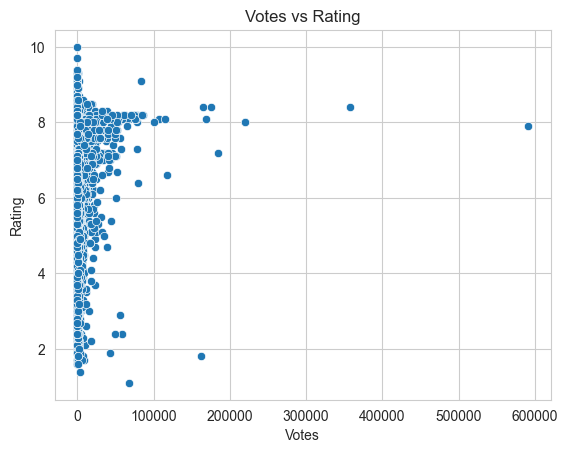

In [52]:
plt.figure()
sns.scatterplot(x=df['Votes'], y=df['Rating'])
plt.title("Votes vs Rating")
plt.show()

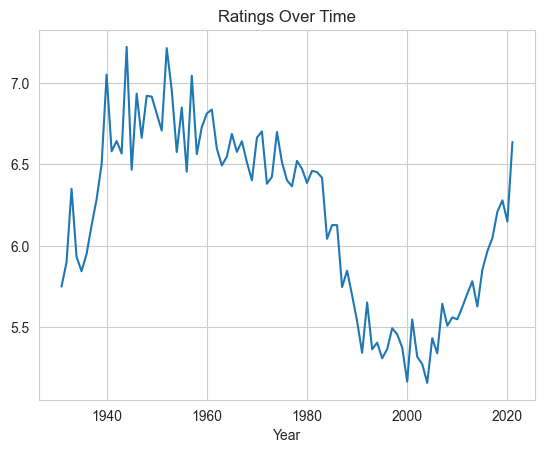

In [53]:
year_trend = df.groupby('Year')['Rating'].mean()

plt.figure()
year_trend.plot()
plt.title("Ratings Over Time")
plt.show()

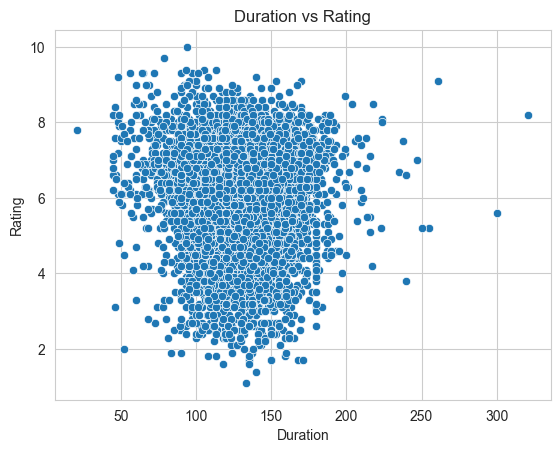

In [54]:
plt.figure()
sns.scatterplot(x=df['Duration'], y=df['Rating'])
plt.title("Duration vs Rating")
plt.show()

In [55]:
genre_analysis = df.groupby('Genre').agg({
    'Rating': 'mean',
    'Votes': 'mean'
}).sort_values(by='Rating', ascending=False)

print(genre_analysis.head(10))

       Rating   Votes
Genre                
332      9.40    47.0
237      9.30    36.0
240      8.90    94.0
243      8.70  1928.0
242      8.60  7711.0
225      8.50    13.0
143      8.30    29.0
122      8.30     6.0
224      8.25    18.5
344      8.25    29.0


## Feature Engineering

In [56]:
# Combine actors into one feature
df['Actors'] = df['Actor 1'] + " " + df['Actor 2'] + " " + df['Actor 3']

# Encode categorical variables
le = LabelEncoder()

df['Genre'] = le.fit_transform(df['Genre'])
df['Director'] = le.fit_transform(df['Director'])
df['Actors'] = le.fit_transform(df['Actors'])

## Feature Selection


In [57]:

features = ['Genre', 'Director', 'Actors', 'Year', 'Duration', 'Votes']
target = 'Rating'

X = df[features]
y = df[target]

In [58]:
print(X.dtypes)

Genre         int64
Director      int64
Actors        int64
Year          int64
Duration    float64
Votes         int64
dtype: object


In [59]:
X = X.apply(pd.to_numeric, errors='coerce')

In [60]:
X.fillna(0, inplace=True)

,Genre,Director,Actors,Year,Duration,Votes
1,246,660,3897,2019,109.0,8
3,187,1406,3363,2019,110.0,35
5,160,1605,1126,1997,147.0,827
6,306,2143,2099,2005,142.0,1086
8,337,144,5589,2012,82.0,326
...,...,...,...,...,...,...
15493,246,1285,5385,2015,115.0,408
15494,136,2158,2301,2001,153.0,1496
15503,28,1882,1177,1989,125.0,44
15505,38,1074,365,1999,129.0,655


In [61]:
# 6. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Model Training

In [62]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [63]:
#  Predictions

lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

#  Evaluation Function

def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Performance:")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))


In [64]:
# Evaluate both models
evaluate_model("Linear Regression", y_test, lr_pred)
evaluate_model("Random Forest", y_test, rf_pred)


Linear Regression Performance:
MAE: 1.0544288345833828
MSE: 1.7637858693236188
R2 Score: 0.05199125353817946

Random Forest Performance:
MAE: 0.8428420153714773
MSE: 1.2464047241673781
R2 Score: 0.330075945899753


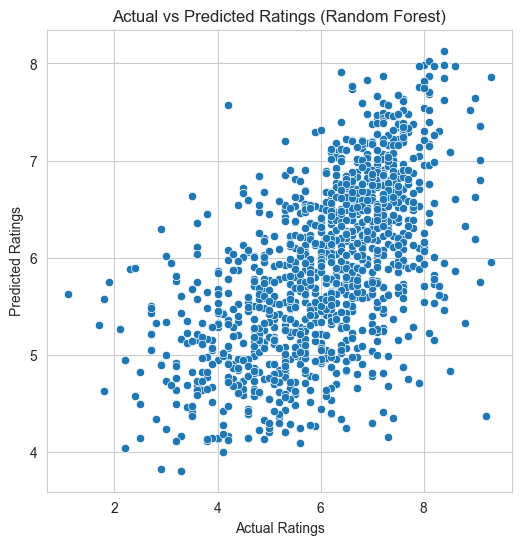

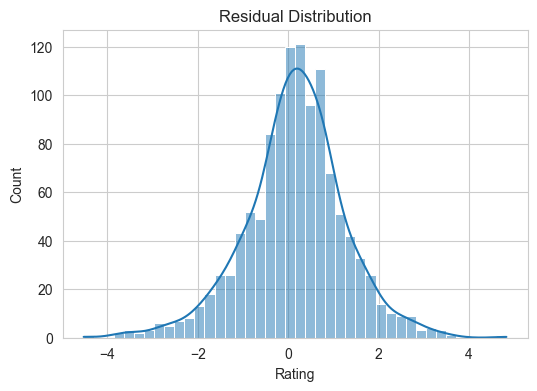

In [65]:
# 10. Visualization
# ==============================

# Actual vs Predicted (Random Forest)
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=rf_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings (Random Forest)")
plt.show()

# Residual Plot
residuals = y_test - rf_pred
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

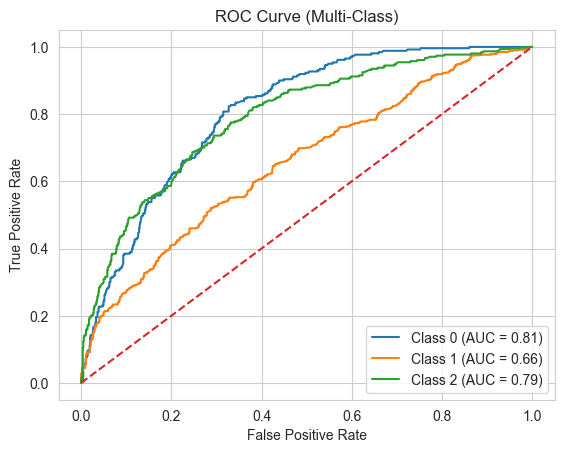

In [66]:
# =========================================
# ROC CURVE + AUC (MULTI-CLASS)
# =========================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier

# =========================================
# 1. Convert Ratings to Categories
# =========================================
def rating_category(r):
    if r <= 5:
        return 0   # Low
    elif r <= 7:
        return 1   # Medium
    else:
        return 2   # High

y_cat = y.apply(rating_category)

# =========================================
# 2. Train Classification Model
# =========================================
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

model = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
model.fit(X_train_c, y_train_c)

# =========================================
# 3. Binarize Labels (for ROC)
# =========================================
y_test_bin = label_binarize(y_test_c, classes=[0, 1, 2])
y_score = model.predict_proba(X_test_c)

# =========================================
# 4. Plot ROC Curve
# =========================================
plt.figure()

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-Class)")
plt.legend()
plt.show()